In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the MNIST dataset
(x_train, y_train_orig), (x_test, y_test_orig) = mnist.load_data()

In [4]:
x_train.shape, y_train_orig.shape, x_test.shape, y_test_orig.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
# Normalize the pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
y_test_orig

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [6]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train_orig, 10)
y_test = to_categorical(y_test_orig, 10)

In [7]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
# Build the ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)),      # Flatten 28x28 images to 784 vector
    Dense(128, activation='relu'),      # Hidden layer with 128 neurons
    Dense(64, activation='relu'),       # Another hidden layer
    Dense(10, activation='softmax')     # Output layer for 10 classes
])

/Users/geethikapanikker/ai-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7809 - loss: 5.2276 - val_accuracy: 0.8871 - val_loss: 0.4455
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - accuracy: 0.9056 - loss: 0.3805 - val_accuracy: 0.9262 - val_loss: 0.2980
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - accuracy: 0.9349 - loss: 0.2440 - val_accuracy: 0.9399 - val_loss: 0.2440
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 963us/step - accuracy: 0.9483 - loss: 0.1921 - val_accuracy: 0.9457 - val_loss: 0.2224
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.9540 - loss: 0.1645 - val_accuracy: 0.9560 - val_loss: 0.1732
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.9601 - loss: 0.1434 - val_accuracy: 0.9603 - val_loss: 0.1563
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9669 - loss: 0.1209 - val_accuracy: 0.9597 - val_loss: 0.1661
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.9671 - los

In [11]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - accuracy: 0.9581 - loss: 0.1968

Test Accuracy: 0.9618


In [12]:
# Optional: This saves the model so it can be loaded in a new script for prediction.
model.save("mnist_ann_model.h5")

#### Visualize the network

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

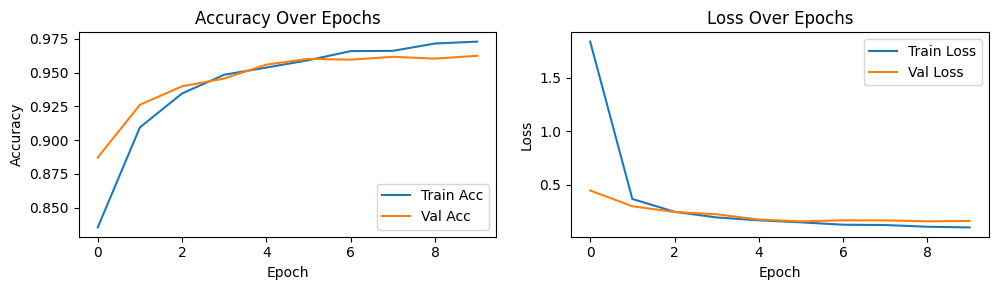

In [14]:
# Plot Accuracy 
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#plt.grid(True)

# Plot Loss

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

##### Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step


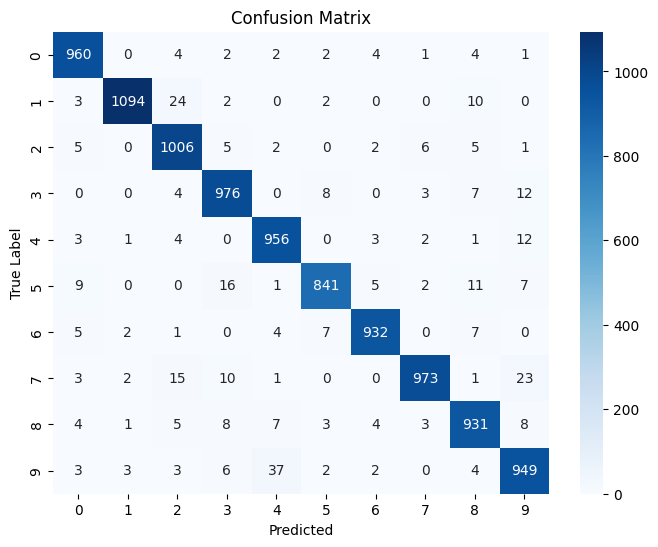

In [15]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test_orig, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()

##### Show Predictions for Sample Digits

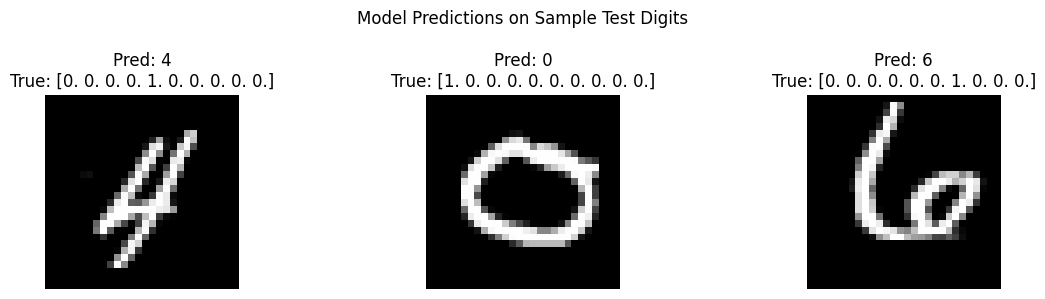

In [18]:
num_samples = 3
indices = np.random.choice(len(x_test), num_samples, replace=False)
sample_images = x_test[indices]
true_labels = y_test[indices]
predicted_labels = y_pred_classes[indices]

plt.figure(figsize=(12, 3))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis('off')
plt.suptitle("Model Predictions on Sample Test Digits")
plt.tight_layout()
plt.show()